# Análisis Exploratorio de Datos (EDA) - Superstore Sales

## 1. Documentación del Dataset

- **Nombre del Dataset:** Superstore Sales Data
- **Fuente:** Datos de ventas de una supertienda (comúnmente utilizado para análisis de negocio).
- **Contexto del Problema:** Este dataset contiene información detallada sobre las ventas de una supertienda, incluyendo datos de clientes, productos, pedidos y ganancias. El objetivo principal es realizar un análisis exploratorio para entender los patrones de ventas, identificar factores que influyen en la rentabilidad y descubrir oportunidades de mejora.
- **Dimensiones:** Se determinarán al cargar el dataset, pero se espera que contenga varias columnas relacionadas con pedidos, productos, clientes y métricas financieras.
- **Tipo de Problema:** Análisis de Negocio, Estadística Descriptiva, Identificación de Patrones, Preparación para Modelado Predictivo (si se busca predecir ganancias o ventas).
- **Variable Objetivo:** `Profit` (Ganancia).
- **Integrantes del Equipo:**
    - Camilo Velasquez Restrepo
    - Mateo del Rio Usma
    - Daniela Cadavid Henao

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración de visualización
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 100

# Cargar el dataset
try:
    df = pd.read_csv('sample_-_superstore.csv', encoding='latin1') # Intentar con latin1 si utf-8 falla
except UnicodeDecodeError:
    df = pd.read_csv('sample_-_superstore.csv', encoding='utf-8')

print("Dataset cargado exitosamente.")

Dataset cargado exitosamente.


## 2. Inspección Inicial del Dataset

En esta sección, realizaremos una primera inspección para comprender la estructura básica del dataset, los tipos de datos y algunas estadísticas descriptivas.

In [28]:
print("\n--- Primeras 5 filas del dataset ---")
display(df.head())

print("\n--- Información general del dataset ---")
df.info()

print("\n--- Estadísticas descriptivas de variables numéricas ---")
display(df.describe())

print("\n--- Forma del dataset (filas, columnas) ---")
print(df.shape)


--- Primeras 5 filas del dataset ---


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,US-2023-103800,01/03/2023,01/07/2023,Standard Class,DP-13000,Darren Powers,Consumer,United States,Houston,...,77095,Central,OFF-PA-10000174,Office Supplies,Paper,"Message Book, Wirebound, Four 5 1/2"" X 4"" Form...",16.448,2,0.2,5.5512
1,2,US-2023-112326,01/04/2023,01/08/2023,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-BI-10004094,Office Supplies,Binders,GBC Standard Plastic Binding Systems Combs,3.540,2,0.8,-5.4870
2,3,US-2023-112326,01/04/2023,01/08/2023,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-LA-10003223,Office Supplies,Labels,Avery 508,11.784,3,0.2,4.2717
3,4,US-2023-112326,01/04/2023,01/08/2023,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-ST-10002743,Office Supplies,Storage,SAFCO Boltless Steel Shelving,272.736,3,0.2,-64.7748
4,5,US-2023-141817,01/05/2023,01/12/2023,Standard Class,MB-18085,Mick Brown,Consumer,United States,Philadelphia,...,19143,East,OFF-AR-10003478,Office Supplies,Art,Avery Hi-Liter EverBold Pen Style Fluorescent ...,19.536,3,0.2,4.8840



--- Información general del dataset ---
<class 'pandas.DataFrame'>
RangeIndex: 10194 entries, 0 to 10193
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Row ID          10194 non-null  int64  
 1   Order ID        10194 non-null  str    
 2   Order Date      10194 non-null  str    
 3   Ship Date       10194 non-null  str    
 4   Ship Mode       10194 non-null  str    
 5   Customer ID     10194 non-null  str    
 6   Customer Name   10194 non-null  str    
 7   Segment         10194 non-null  str    
 8   Country/Region  10194 non-null  str    
 9   City            10194 non-null  str    
 10  State/Province  10194 non-null  str    
 11  Postal Code     10194 non-null  str    
 12  Region          10194 non-null  str    
 13  Product ID      10194 non-null  str    
 14  Category        10194 non-null  str    
 15  Sub-Category    10194 non-null  str    
 16  Product Name    10194 non-null  str    
 17  S

,Row ID,Sales,Quantity,Discount,Profit
count,10194.000000,10194.000000,10194.000000,10194.000000,10194.000000
mean,5097.500000,228.225854,3.791838,0.155385,28.673417
std,2942.898656,619.906839,2.228317,0.206249,232.465115
min,1.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2549.250000,17.220000,2.000000,0.000000,1.760800
50%,5097.500000,53.910000,3.000000,0.200000,8.690000
75%,7645.750000,209.500000,5.000000,0.200000,29.297925
max,10194.000000,22638.480000,14.000000,0.800000,8399.976000



--- Forma del dataset (filas, columnas) ---
(10194, 21)


In [29]:
# Convertir 'Order Date' y 'Ship Date' a formato de fecha
df['Order Date'] = pd.to_datetime(df['Order Date'], format='%m/%d/%Y')
df['Ship Date'] = pd.to_datetime(df['Ship Date'], format='%m/%d/%Y')
print("\n'Order Date' y 'Ship Date' convertidas a formato de fecha.")


'Order Date' y 'Ship Date' convertidas a formato de fecha.


## 3. Análisis de Valores Faltantes

Identificaremos la presencia de valores nulos en cada columna y decidiremos una estrategia de tratamiento justificada.


--- Conteo de valores faltantes por columna ---
Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country/Region    0
City              0
State/Province    0
Postal Code       0
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
Quantity          0
Discount          0
Profit            0
dtype: int64


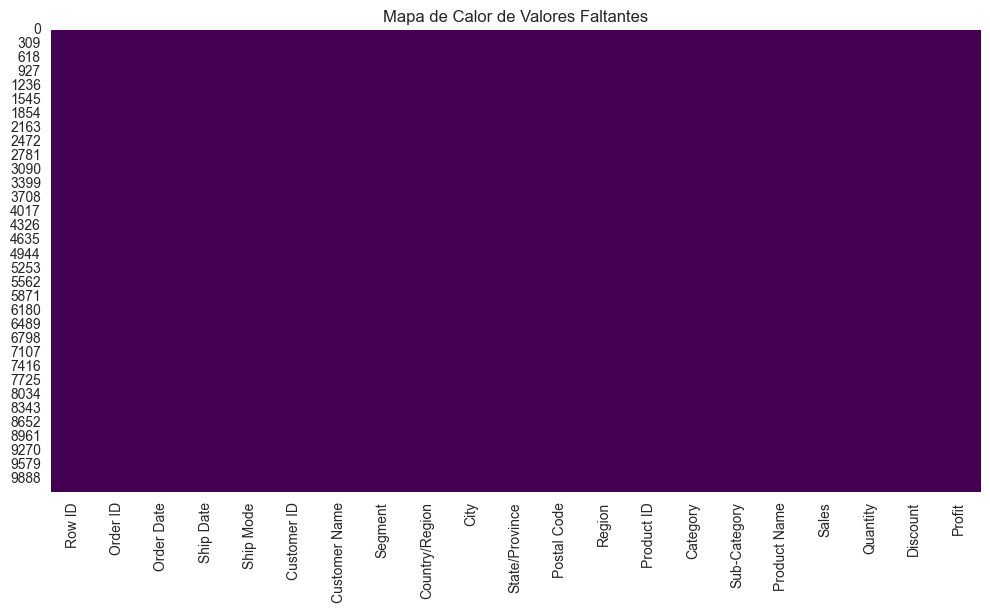

In [30]:
print("\n--- Conteo de valores faltantes por columna ---")
missing_values = df.isnull().sum()
print(missing_values)

# Visualización de valores faltantes
plt.figure(figsize=(12, 6))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title('Mapa de Calor de Valores Faltantes')
plt.show()

## 4. Distribución de la Variable Objetivo: `Profit`

Analizaremos la distribución de la variable `Profit` para entender su comportamiento, identificar posibles sesgos y la presencia de valores atípicos.


--- Estadísticas descriptivas de la variable objetivo 'Profit' ---


count    10194.000000
mean        28.673417
std        232.465115
min      -6599.978000
25%          1.760800
50%          8.690000
75%         29.297925
max       8399.976000
Name: Profit, dtype: float64

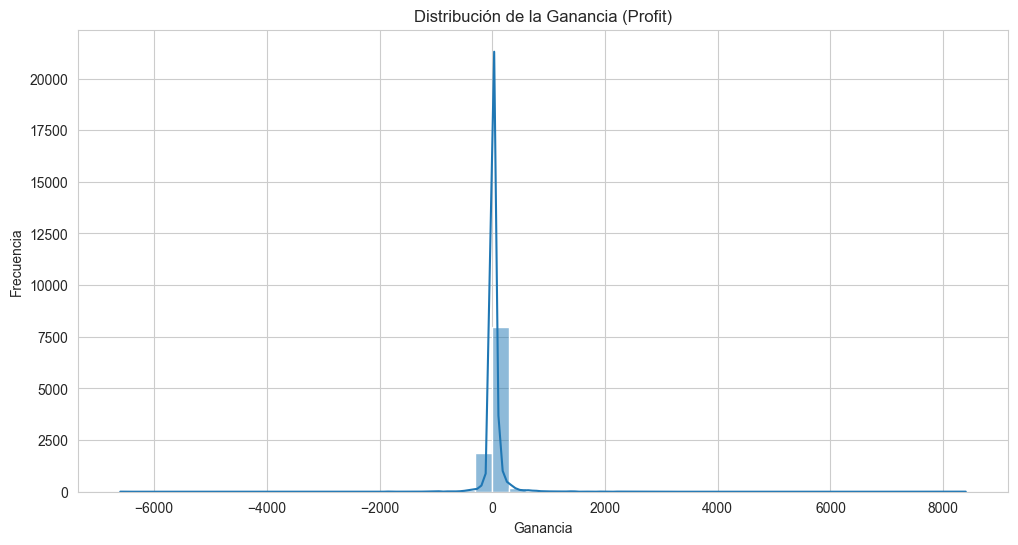

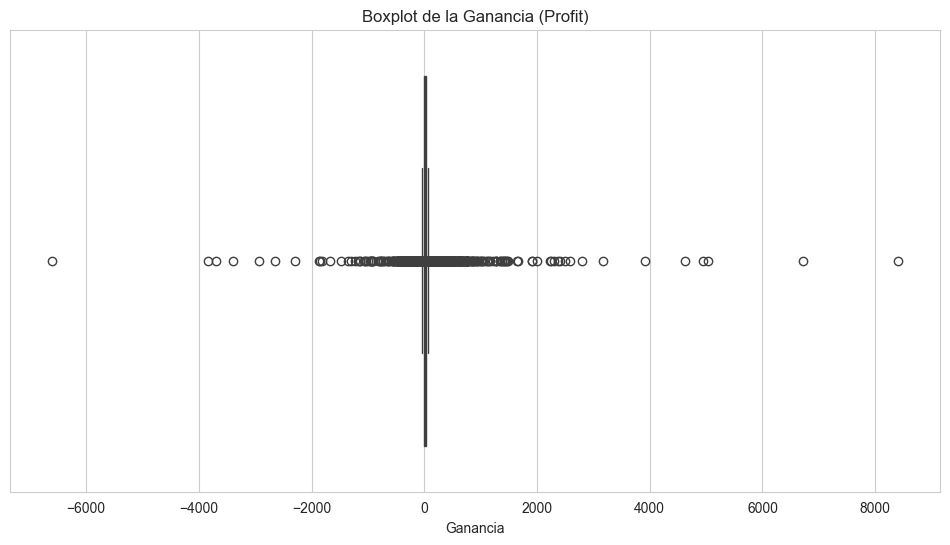

Sesgo de 'Profit': 7.60
Curtosis de 'Profit': 401.69
Número de transacciones con pérdida o sin ganancia: 1966 (19.29%)


In [31]:
print("\n--- Estadísticas descriptivas de la variable objetivo 'Profit' ---")
display(df['Profit'].describe())

plt.figure(figsize=(12, 6))
sns.histplot(df['Profit'], bins=50, kde=True)
plt.title('Distribución de la Ganancia (Profit)')
plt.xlabel('Ganancia')
plt.ylabel('Frecuencia')
plt.show()

plt.figure(figsize=(12, 6))
sns.boxplot(x=df['Profit'])
plt.title('Boxplot de la Ganancia (Profit)')
plt.xlabel('Ganancia')
plt.show()

print(f"Sesgo de 'Profit': {df['Profit'].skew():.2f}")
print(f"Curtosis de 'Profit': {df['Profit'].kurt():.2f}")

# Conteo de valores de Profit <= 0 (pérdidas o sin ganancia)
loss_count = df[df['Profit'] <= 0].shape[0]
total_count = df.shape[0]
print(f"Número de transacciones con pérdida o sin ganancia: {loss_count} ({loss_count/total_count:.2%})")

## 5. Análisis Univariado de Variables Numéricas y Categóricas

Exploraremos la distribución de las variables individuales, identificando patrones, rangos y la presencia de outliers.


--- Análisis Univariado de Variables Numéricas ---

Variable: Sales


count    10194.000000
mean       228.225854
std        619.906839
min          0.444000
25%         17.220000
50%         53.910000
75%        209.500000
max      22638.480000
Name: Sales, dtype: float64

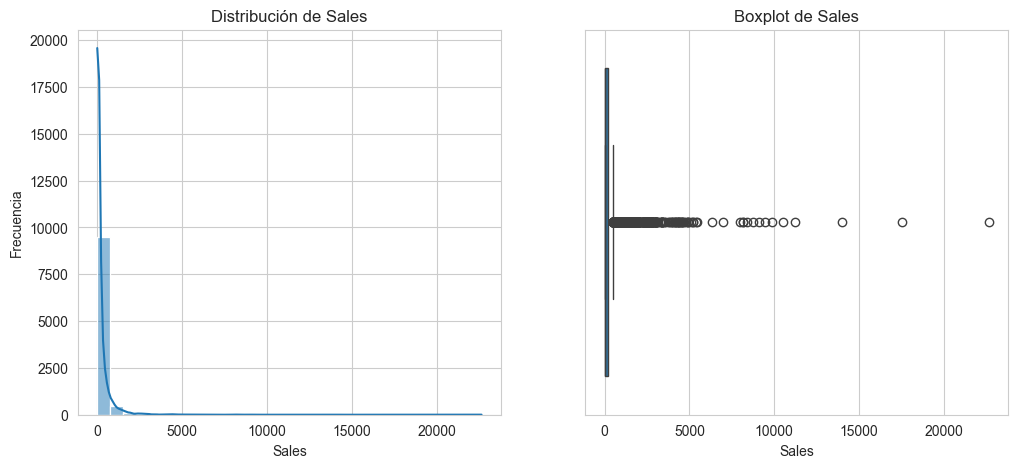

Sesgo de 'Sales': 12.98
Curtosis de 'Sales': 306.37

Variable: Quantity


count    10194.000000
mean         3.791838
std          2.228317
min          1.000000
25%          2.000000
50%          3.000000
75%          5.000000
max         14.000000
Name: Quantity, dtype: float64

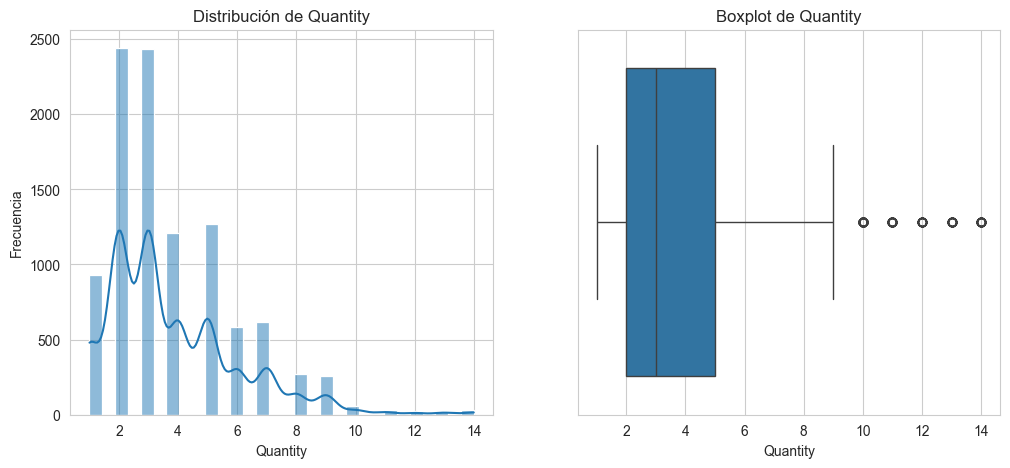

Sesgo de 'Quantity': 1.27
Curtosis de 'Quantity': 1.96

Variable: Discount


count    10194.000000
mean         0.155385
std          0.206249
min          0.000000
25%          0.000000
50%          0.200000
75%          0.200000
max          0.800000
Name: Discount, dtype: float64

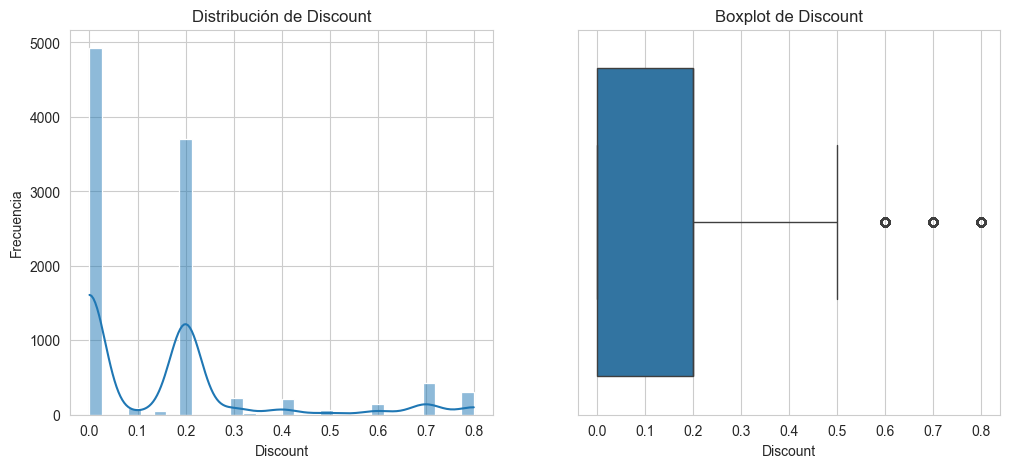

Sesgo de 'Discount': 1.69
Curtosis de 'Discount': 2.42


In [32]:
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()
numerical_cols.remove('Profit') # Ya analizamos Profit
if 'Row ID' in numerical_cols: numerical_cols.remove('Row ID') # Eliminar ID 
if 'Postal Code' in numerical_cols: numerical_cols.remove('Postal Code') # Eliminar Postal Code ya que sería redundante con la variable de ciudad

print("\n--- Análisis Univariado de Variables Numéricas ---")
for col in numerical_cols:
    print(f"\nVariable: {col}")
    display(df[col].describe())
    
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    sns.histplot(df[col], bins=30, kde=True)
    plt.title(f'Distribución de {col}')
    plt.xlabel(col)
    plt.ylabel('Frecuencia')
    
    plt.subplot(1, 2, 2)
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot de {col}')
    plt.xlabel(col)
    plt.show()
    print(f"Sesgo de '{col}': {df[col].skew():.2f}")
    print(f"Curtosis de '{col}': {df[col].kurt():.2f}")


--- Análisis Univariado de Variables Categóricas ---
Variables categóricas identificadas: ['Ship Mode', 'Segment', 'Country/Region', 'City', 'State/Province', 'Region', 'Category', 'Sub-Category']

Variable: Ship Mode


Ship Mode
Standard Class    6120
Second Class      1979
First Class       1548
Same Day           547
Name: count, dtype: int64

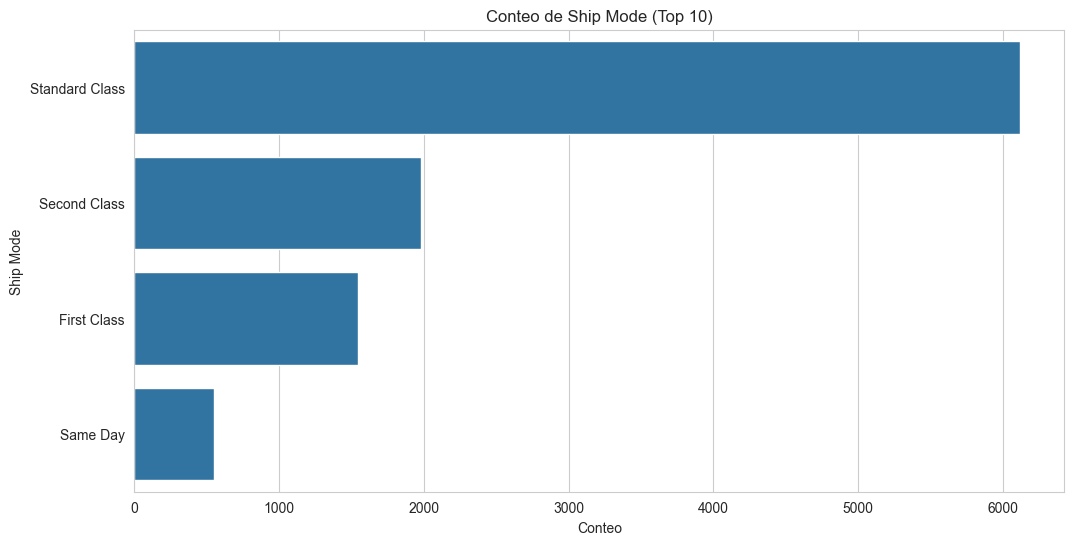


Variable: Segment


Segment
Consumer       5281
Corporate      3090
Home Office    1823
Name: count, dtype: int64

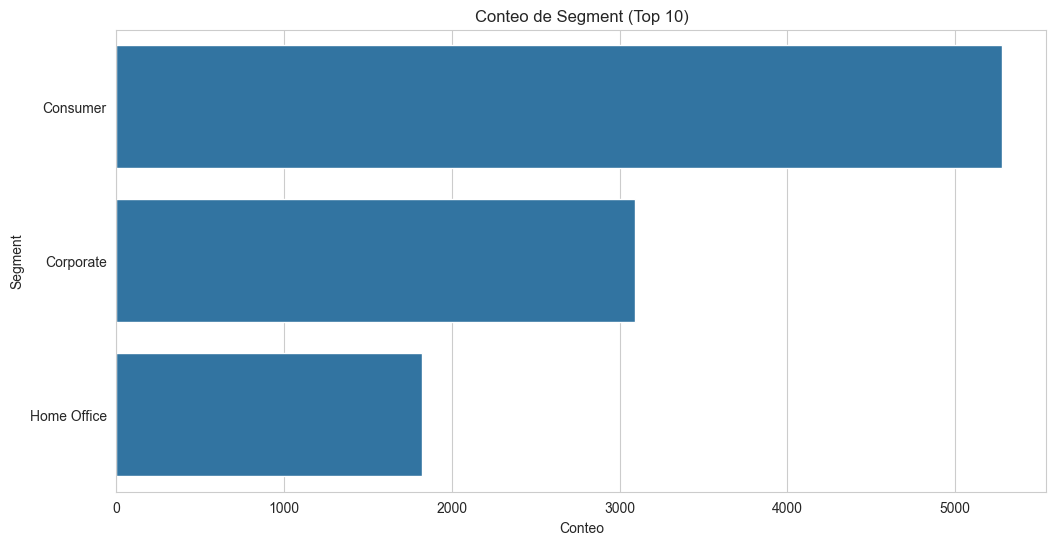


Variable: Country/Region


Country/Region
United States    9994
Canada            200
Name: count, dtype: int64

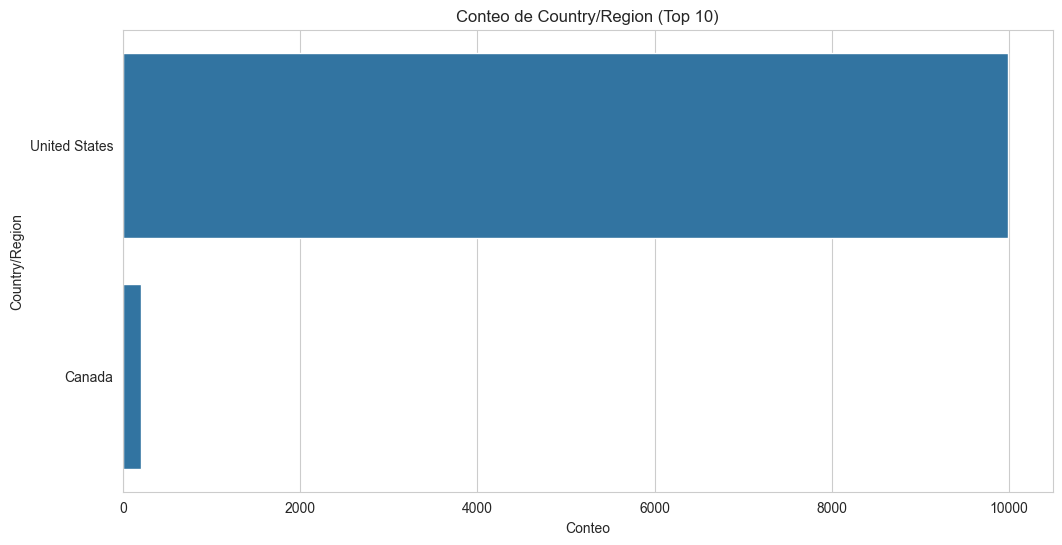


Variable: City


City
New York City    915
Los Angeles      747
Philadelphia     537
San Francisco    510
Seattle          428
Houston          377
Chicago          314
Columbus         222
San Diego        170
Springfield      163
Name: count, dtype: int64

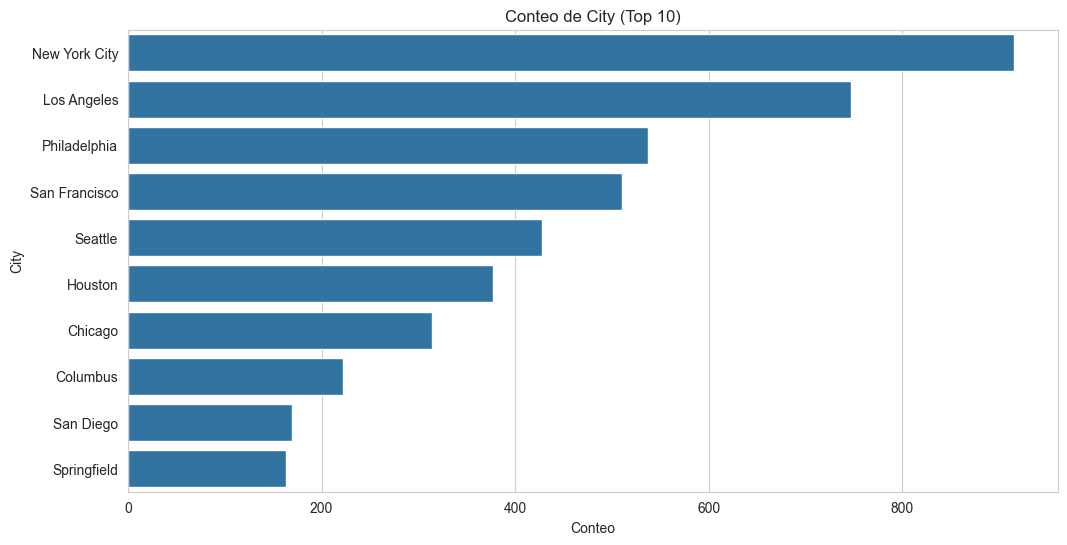


Variable: State/Province


State/Province
California        2001
New York          1128
Texas              985
Pennsylvania       587
Washington         506
Illinois           492
Ohio               469
Florida            383
Michigan           255
North Carolina     249
Name: count, dtype: int64

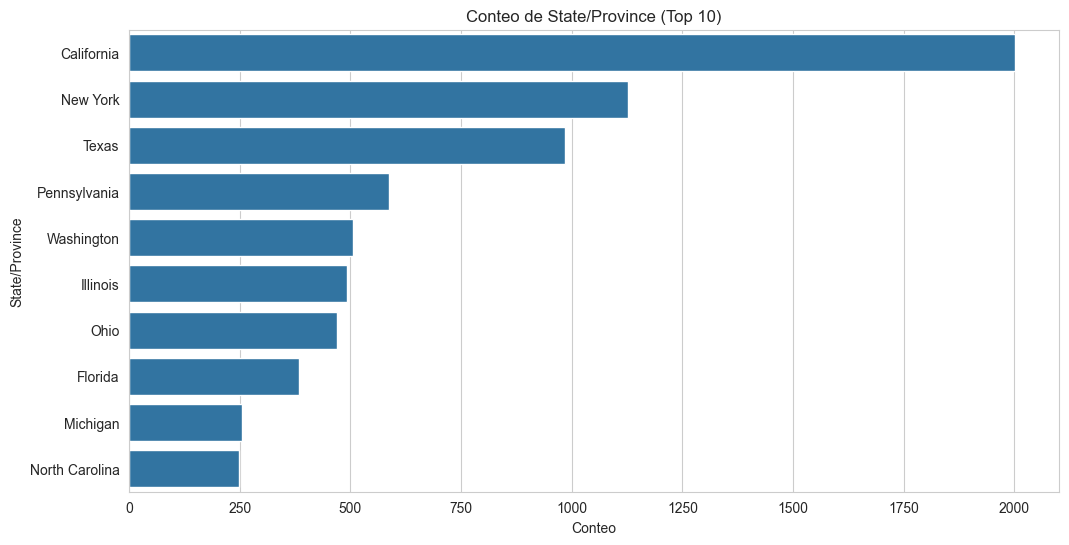


Variable: Region


Region
West       3253
East       2986
Central    2335
South      1620
Name: count, dtype: int64

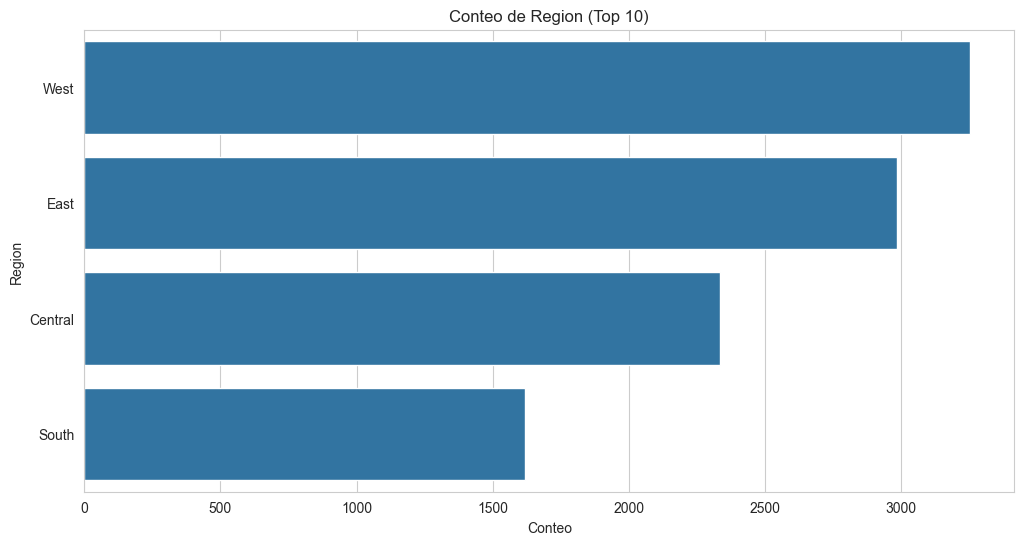


Variable: Category


Category
Office Supplies    6128
Furniture          2201
Technology         1865
Name: count, dtype: int64

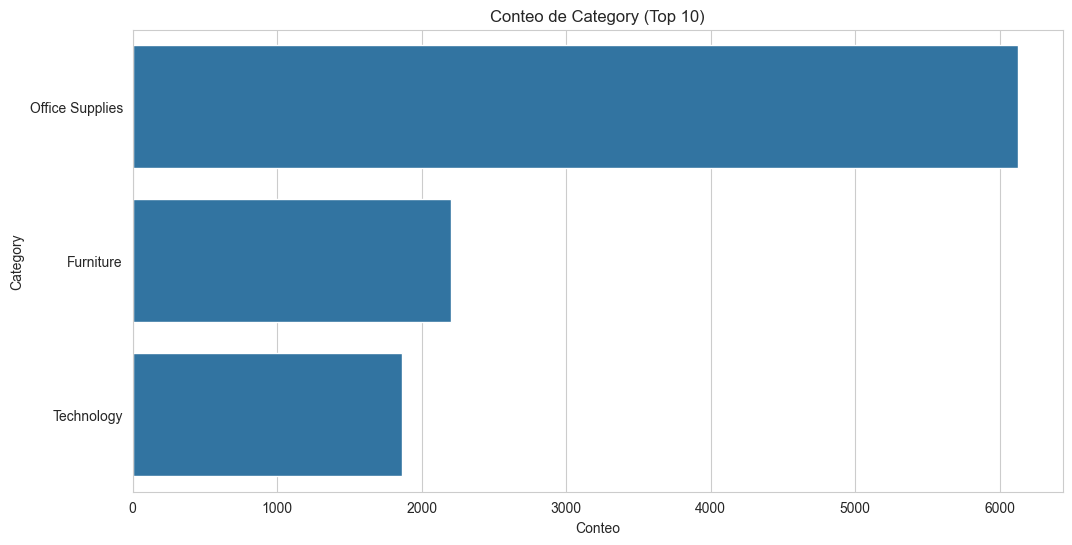


Variable: Sub-Category


Sub-Category
Binders        1548
Paper          1384
Furnishings    1009
Phones          903
Storage         856
Art             821
Accessories     775
Chairs          634
Appliances      474
Labels          368
Name: count, dtype: int64

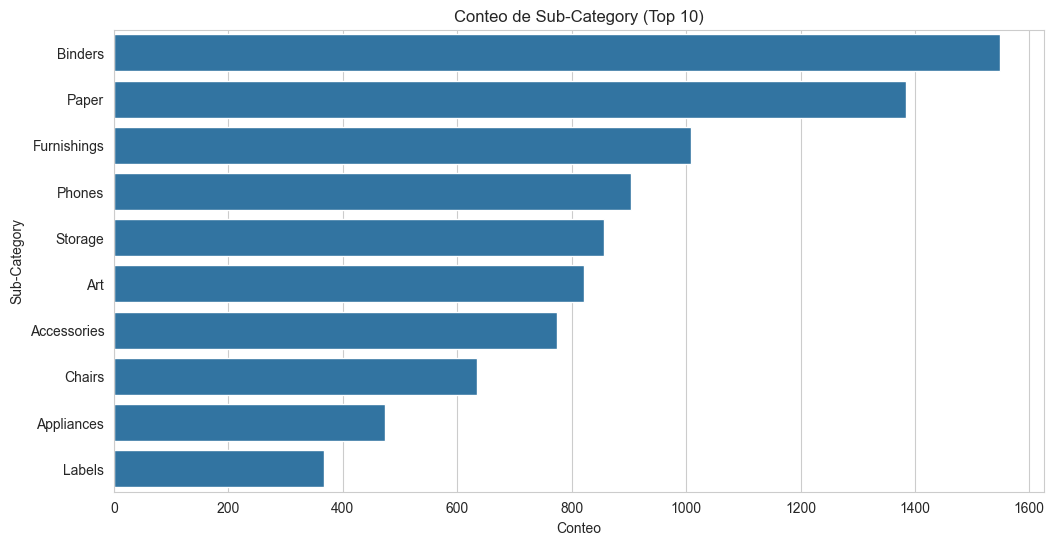

In [33]:
categorical_cols = df.select_dtypes(include=['object', 'string']).columns.tolist()
if 'Order ID' in categorical_cols: categorical_cols.remove('Order ID') # Eliminar ID si existe
if 'Customer ID' in categorical_cols: categorical_cols.remove('Customer ID') # Eliminar ID si existe
if 'Product ID' in categorical_cols: categorical_cols.remove('Product ID') # Eliminar ID si existe
if 'Customer Name' in categorical_cols: categorical_cols.remove('Customer Name') # Eliminar nombre si existe
if 'Product Name' in categorical_cols: categorical_cols.remove('Product Name') # Eliminar nombre si existe
if 'Postal Code' in categorical_cols: categorical_cols.remove('Postal Code') # Eliminar Postal Code ya que sería redundante con la variable de ciudad

print("\n--- Análisis Univariado de Variables Categóricas ---")
print(f"Variables categóricas identificadas: {categorical_cols}")

for col in categorical_cols:
    print(f"\nVariable: {col}")
    
    # 1. Obtener el conteo de las 10 categorías más frecuentes
    top_10 = df[col].value_counts().head(10)
    display(top_10)
    
    plt.figure(figsize=(12, 6))
    
    # 2. Filtrar el DataFrame para graficar solo el Top 10
    df_filtered = df[df[col].isin(top_10.index)]
    sns.countplot(y=df_filtered[col], order=top_10.index)
    
    plt.title(f'Conteo de {col} (Top 10)')
    plt.xlabel('Conteo')
    plt.ylabel(col)
    plt.show()

## 6. Análisis Bivariado: Relación entre Features y Target (`Profit`)

Investigaremos cómo las diferentes variables se relacionan con la ganancia (`Profit`).


--- Correlación entre variables numéricas y 'Profit' ---


Profit      1.000000
Sales       0.481460
Quantity    0.066145
Discount   -0.218882
Name: Profit, dtype: float64

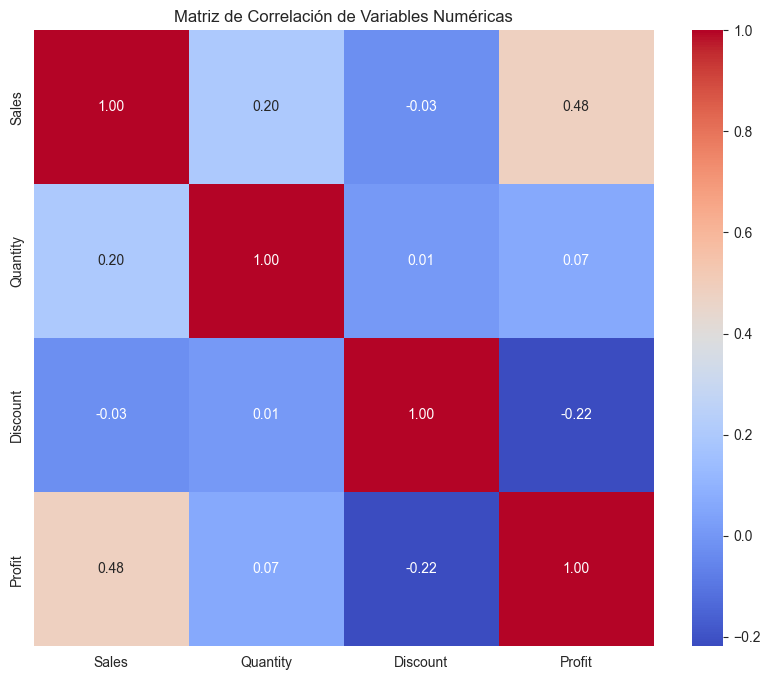

In [34]:
print("\n--- Correlación entre variables numéricas y 'Profit' ---")
correlation_matrix = df[numerical_cols + ['Profit']].corr()
display(correlation_matrix['Profit'].sort_values(ascending=False))

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matriz de Correlación de Variables Numéricas')
plt.show()


--- Scatterplots de variables numéricas vs. 'Profit' ---


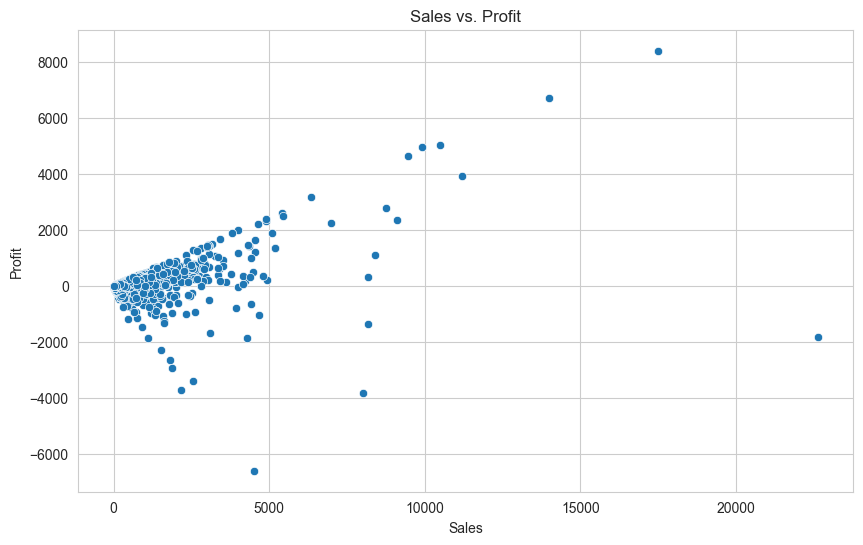

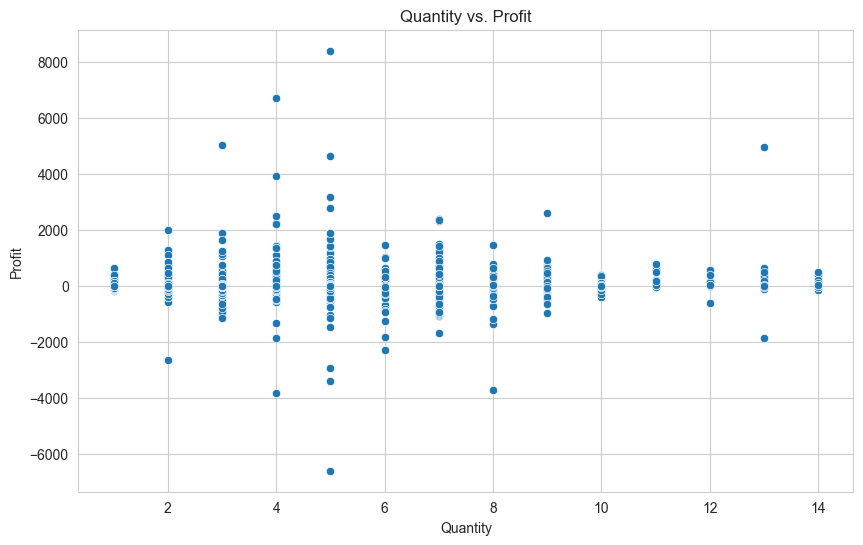

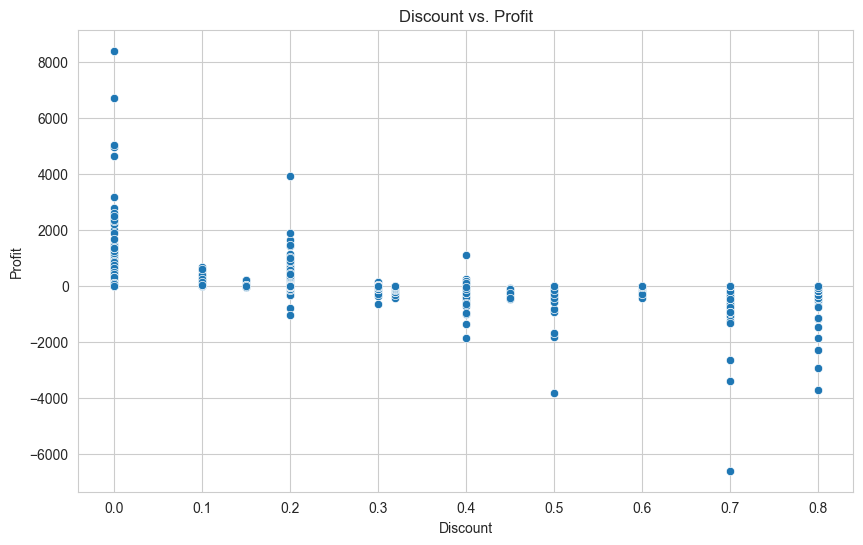


--- Boxplots de variables categóricas vs. 'Profit' ---


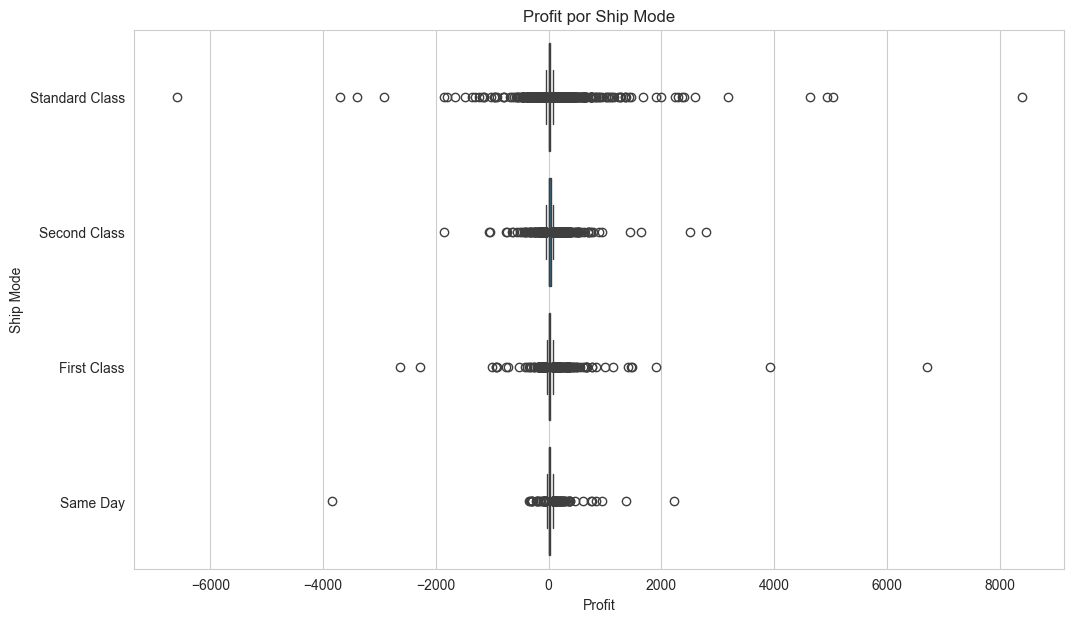

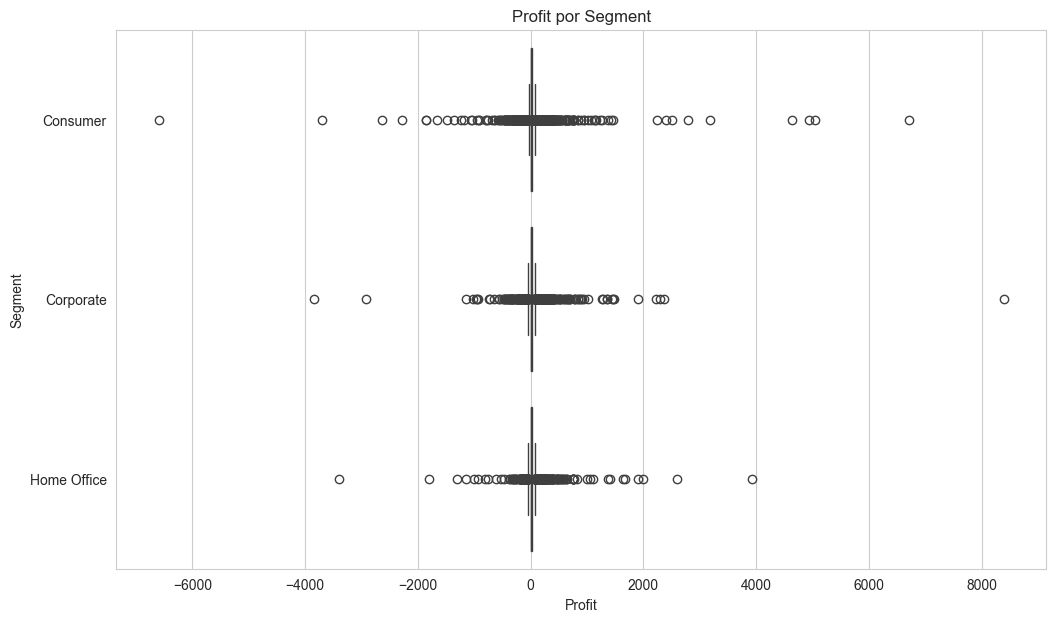

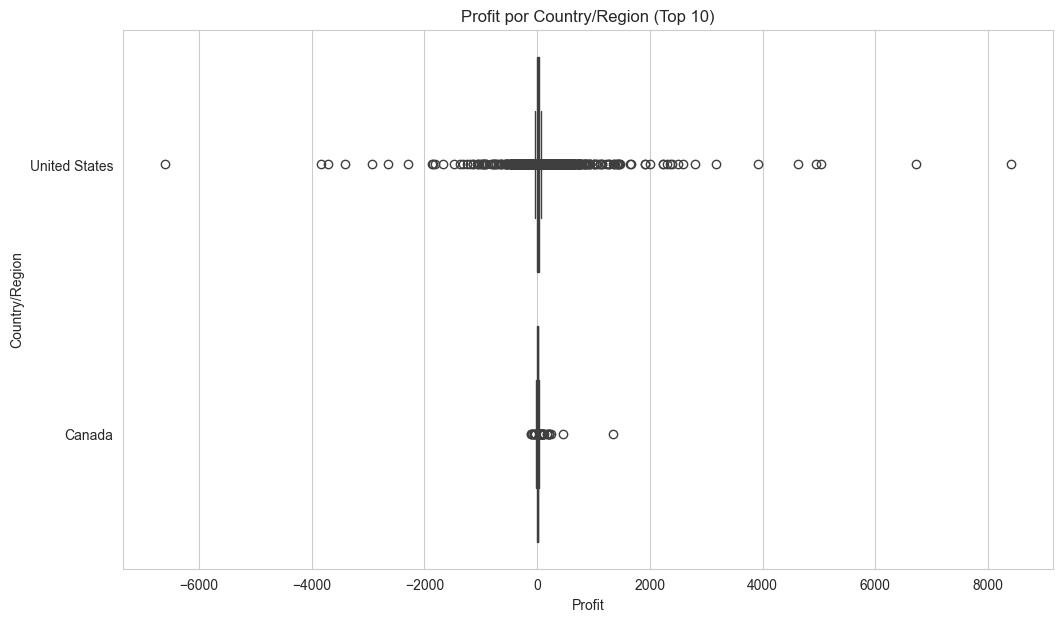

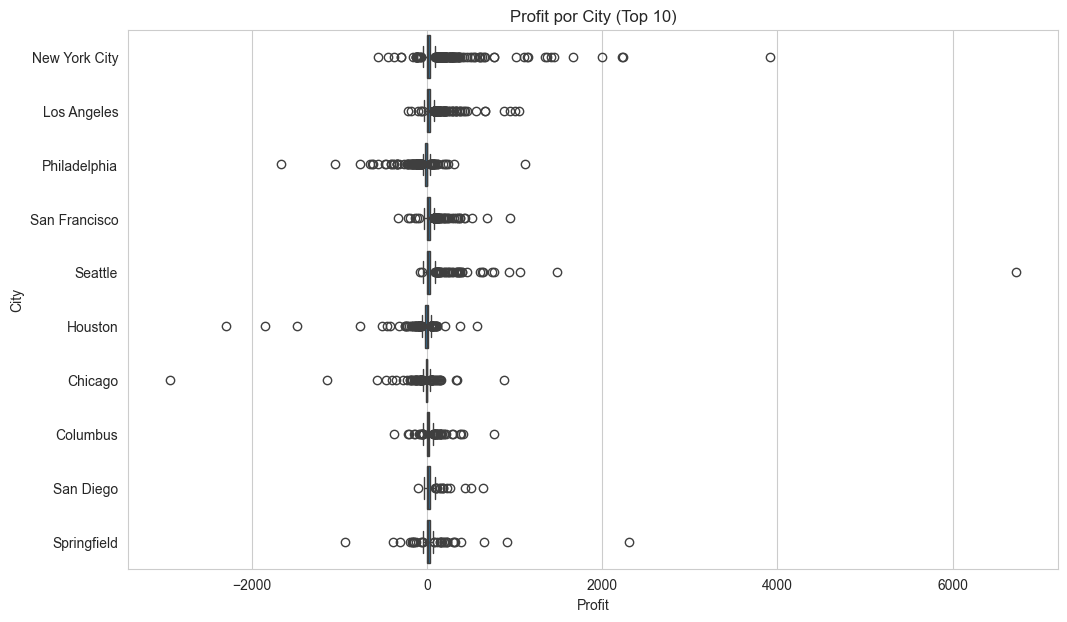

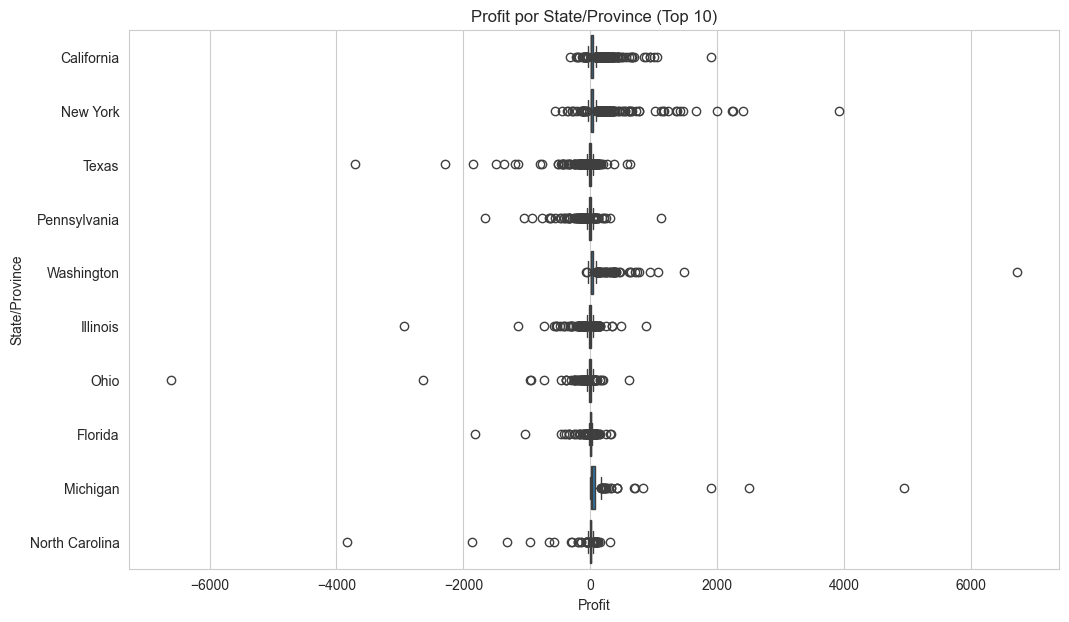

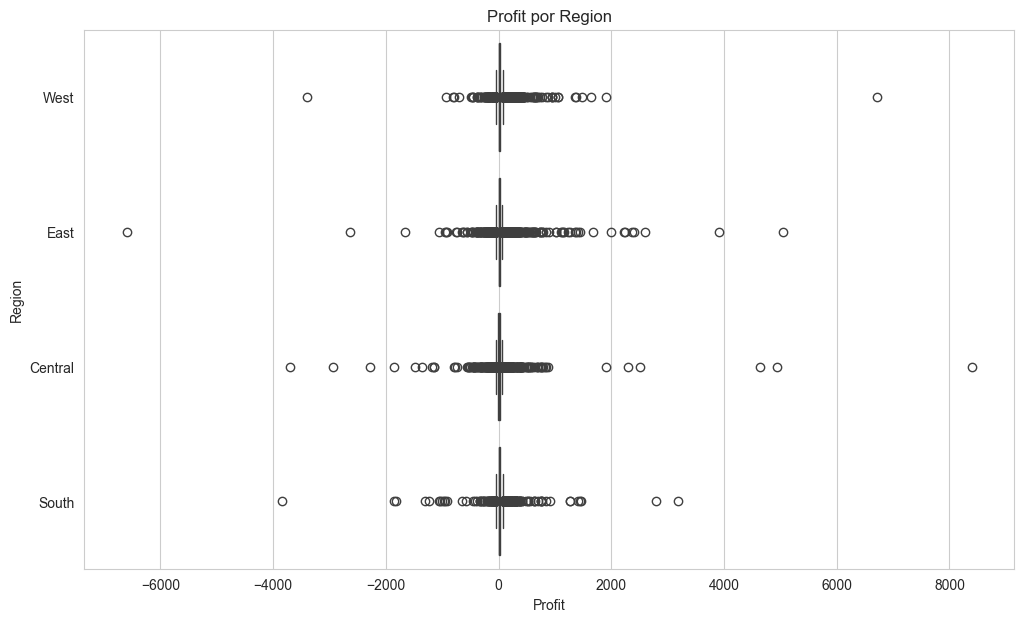

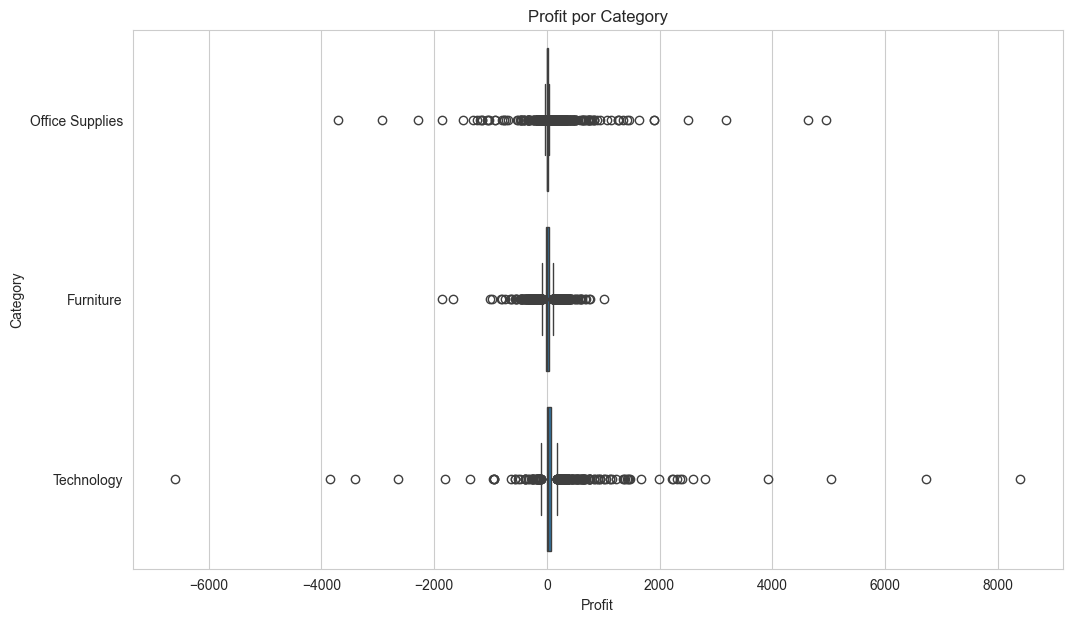

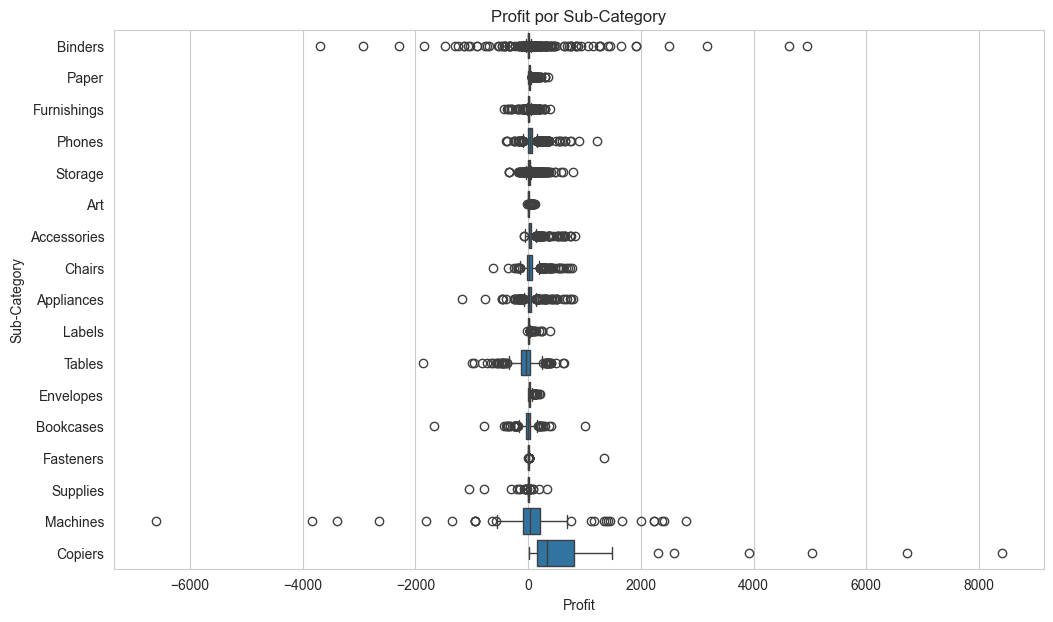

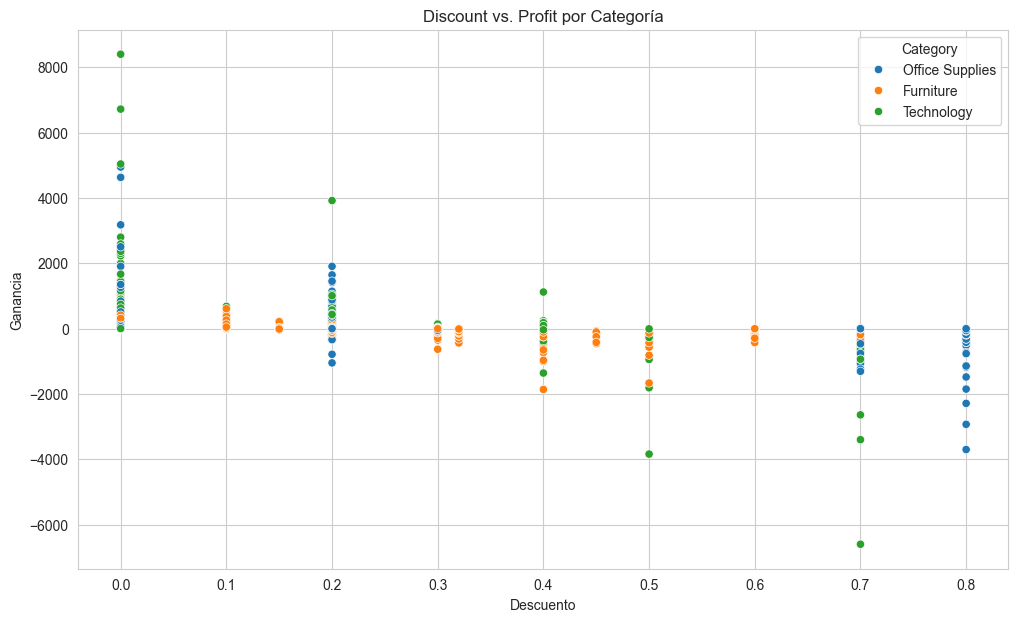

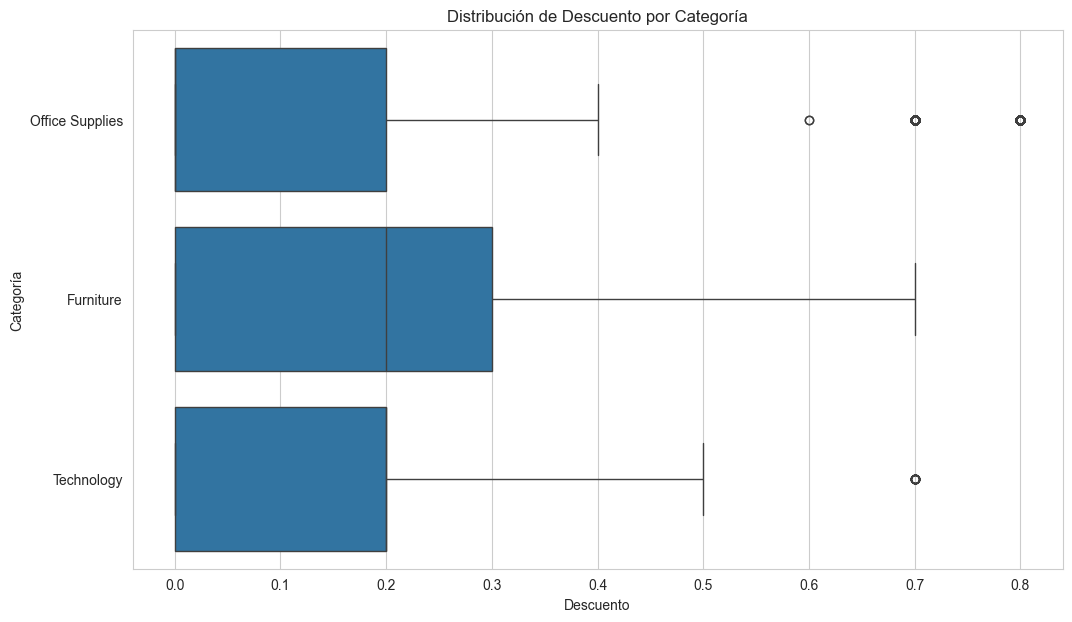

In [35]:
print("\n--- Scatterplots de variables numéricas vs. 'Profit' ---")
for col in numerical_cols:
    plt.figure(figsize=(10, 6))
    sns.scatterplot(x=df[col], y=df['Profit'])
    plt.title(f'{col} vs. Profit')
    plt.xlabel(col)
    plt.ylabel('Profit')
    plt.show()

print("\n--- Boxplots de variables categóricas vs. 'Profit' ---")
for col in categorical_cols:
    if col in ['City','Country/Region', 'State/Province']:
        top10_vals = df[col].value_counts().head(10).index
        df_plot = df[df[col].isin(top10_vals)]
        title = f'Profit por {col} (Top 10)'
    else:
        df_plot = df
        top10_vals = df[col].value_counts().index
        title = f'Profit por {col}'

    plt.figure(figsize=(12, 7))
    sns.boxplot(x=df_plot['Profit'], y=df_plot[col], order=top10_vals)
    plt.title(title)
    plt.xlabel('Profit')
    plt.ylabel(col)
    plt.show()

# Análisis de la relación entre Discount y Profit
plt.figure(figsize=(12, 7))
sns.scatterplot(x=df['Discount'], y=df['Profit'], hue=df['Category'])
plt.title('Discount vs. Profit por Categoría')
plt.xlabel('Descuento')
plt.ylabel('Ganancia')
plt.show()

plt.figure(figsize=(12, 7))
sns.boxplot(x=df['Discount'], y=df['Category'])
plt.title('Distribución de Descuento por Categoría')
plt.xlabel('Descuento')
plt.ylabel('Categoría')
plt.show()

## 7. Análisis Geográfico Interactivo (Folium)

Las gráficas anteriores (secciones 4–6) siguen siendo nuestra base descriptiva. En esta sección las **complementamos** con mapas interactivos construidos con `folium` para visualizar la dimensión geográfica de la rentabilidad:

- **Choropleth por estado:** colorea cada estado de EE. UU. según el `Profit` (y las `Sales`) totales.
- **Mapa de burbujas por ciudad:** ubica cada ciudad a partir de su código postal (vía `pgeocode`); el tamaño de la burbuja es proporcional a las ventas y el color indica si la ciudad es rentable (verde) o genera pérdidas (rojo).

> **Nota:** el GeoJSON utilizado contiene únicamente los estados de EE. UU., por lo que las provincias de Canadá y el Distrito de Columbia aparecen en gris en el choropleth. El mapa de ciudades sí cubre ambos países a partir del código postal.

In [36]:
# --- Librerías para mapas interactivos ---
import os
import json
import urllib.request
import folium
import pgeocode

# GeoJSON con los polígonos de los estados de EE. UU.
# Se descarga una sola vez y se cachea localmente para que el notebook sea reproducible.
GEOJSON_URL = "https://raw.githubusercontent.com/python-visualization/folium/main/examples/data/us-states.json"
GEOJSON_PATH = "us-states.json"
if not os.path.exists(GEOJSON_PATH):
    urllib.request.urlretrieve(GEOJSON_URL, GEOJSON_PATH)
with open(GEOJSON_PATH, "r") as f:
    us_states_geojson = json.load(f)

# Centro aproximado de los mapas (EE. UU. continental)
MAP_CENTER = [39.5, -98.35]
print(f"GeoJSON cargado: {len(us_states_geojson['features'])} estados de EE. UU.")

GeoJSON cargado: 50 estados de EE. UU.


### 7.1 Choropleth: rentabilidad y ventas por estado

Agregamos el `Profit` y las `Sales` totales por estado y los proyectamos sobre el mapa. En el choropleth de `Profit`, el rojo señala estados con pérdidas netas y el verde estados rentables.

In [37]:
# Profit total agregado por estado/provincia
state_profit = df.groupby('State/Province', as_index=False)['Profit'].sum()

mapa_profit = folium.Map(location=MAP_CENTER, zoom_start=4, tiles='cartodbpositron')
folium.Choropleth(
    geo_data=us_states_geojson,
    data=state_profit,
    columns=['State/Province', 'Profit'],
    key_on='feature.properties.name',
    fill_color='RdYlGn',           # rojo = pérdidas, verde = ganancias
    nan_fill_color='lightgray',    # estados fuera del GeoJSON (provincias de Canadá, DC)
    fill_opacity=0.85,
    line_opacity=0.3,
    legend_name='Profit total (USD) por estado',
).add_to(mapa_profit)
mapa_profit

In [38]:
# Sales totales agregadas por estado/provincia
state_sales = df.groupby('State/Province', as_index=False)['Sales'].sum()

mapa_sales = folium.Map(location=MAP_CENTER, zoom_start=4, tiles='cartodbpositron')
folium.Choropleth(
    geo_data=us_states_geojson,
    data=state_sales,
    columns=['State/Province', 'Sales'],
    key_on='feature.properties.name',
    fill_color='YlGnBu',
    nan_fill_color='lightgray',
    fill_opacity=0.85,
    line_opacity=0.3,
    legend_name='Ventas totales (USD) por estado',
).add_to(mapa_sales)
mapa_sales

### 7.2 Mapa de burbujas: ventas y rentabilidad por ciudad

Geocodificamos cada registro por su **código postal** (`pgeocode`, distinguiendo EE. UU. de Canadá) y agregamos las métricas por ciudad. Cada burbuja representa una ciudad: su **tamaño** es proporcional a las ventas totales y su **color** indica si la ciudad es rentable (verde) o genera pérdidas (rojo). Haz clic en una burbuja para ver el detalle.

In [39]:
# Geocodificación por código postal según el país.
# pgeocode descarga y cachea los datos de cada país la primera vez que se usa.
def coords_por_codigo_postal(country_code, postal_series):
    nomi = pgeocode.Nominatim(country_code)
    codigos = postal_series.dropna().astype(str).unique().tolist()
    res = nomi.query_postal_code(codigos)[['postal_code', 'latitude', 'longitude']]
    res['postal_code'] = res['postal_code'].astype(str)
    return dict(zip(res['postal_code'], zip(res['latitude'], res['longitude'])))

df['_pc'] = df['Postal Code'].astype(str)
lut = {}
lut.update(coords_por_codigo_postal('us', df.loc[df['Country/Region'] == 'United States', '_pc']))
lut.update(coords_por_codigo_postal('ca', df.loc[df['Country/Region'] == 'Canada', '_pc']))
df['lat'] = df['_pc'].map(lambda p: lut.get(p, (np.nan, np.nan))[0])
df['lon'] = df['_pc'].map(lambda p: lut.get(p, (np.nan, np.nan))[1])

sin_coords = df[['lat', 'lon']].isna().any(axis=1).sum()
print(f"Filas sin coordenada (código postal no resuelto): {sin_coords} de {len(df)} ({sin_coords/len(df):.1%})")

# Agregación de métricas por ciudad
ciudades = (df.dropna(subset=['lat', 'lon'])
              .groupby(['City', 'State/Province'], as_index=False)
              .agg(Sales=('Sales', 'sum'),
                   Profit=('Profit', 'sum'),
                   Pedidos=('Profit', 'size'),
                   lat=('lat', 'mean'),
                   lon=('lon', 'mean')))
print(f"Ciudades geolocalizadas: {len(ciudades)}")

mapa_ciudades = folium.Map(location=MAP_CENTER, zoom_start=4, tiles='cartodbpositron')
sales_max = ciudades['Sales'].max()
for _, r in ciudades.iterrows():
    folium.CircleMarker(
        location=[r['lat'], r['lon']],
        radius=3 + 17 * np.sqrt(r['Sales'] / sales_max),    # tamaño proporcional a las ventas
        color='#2c7a2c' if r['Profit'] >= 0 else '#b22222',  # verde = rentable, rojo = pérdida
        fill=True,
        fill_opacity=0.6,
        weight=1,
        popup=folium.Popup(
            f"<b>{r['City']}, {r['State/Province']}</b><br>"
            f"Ventas: ${r['Sales']:,.0f}<br>"
            f"Profit: ${r['Profit']:,.0f}<br>"
            f"Pedidos: {int(r['Pedidos'])}",
            max_width=260),
    ).add_to(mapa_ciudades)
mapa_ciudades

Filas sin coordenada (código postal no resuelto): 438 de 10194 (4.3%)
Ciudades geolocalizadas: 565


## 8. Análisis Temporal

Exploramos tendencias mensuales de ventas y profit, patrones de estacionalidad por mes y la distribución de días de envío según la modalidad (`Ship Mode`).

In [ ]:
df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month
df['Quarter'] = df['Order Date'].dt.to_period('Q').astype(str)
df['Ship_Days'] = (df['Ship Date'] - df['Order Date']).dt.days

# Tendencia mensual de ventas y profit
monthly = df.groupby(['Year', 'Month']).agg(Sales=('Sales','sum'), Profit=('Profit','sum')).reset_index()
monthly['Periodo'] = pd.to_datetime(monthly[['Year','Month']].assign(day=1))
monthly = monthly.sort_values('Periodo')

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
axes[0].plot(monthly['Periodo'], monthly['Sales'], marker='o', color='steelblue')
axes[0].set_title('Ventas Mensuales')
axes[0].set_ylabel('Ventas (USD)')
axes[1].plot(monthly['Periodo'], monthly['Profit'], marker='o', color='seagreen')
axes[1].axhline(0, color='red', linewidth=0.8, linestyle='--')
axes[1].set_title('Profit Mensual')
axes[1].set_ylabel('Profit (USD)')
plt.tight_layout()
plt.show()

# Estacionalidad por mes (promedio de todos los años)
season = df.groupby('Month').agg(Sales=('Sales','mean'), Profit=('Profit','mean')).reset_index()
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(data=season, x='Month', y='Sales', color='steelblue', ax=axes[0])
axes[0].set_title('Ventas Promedio por Mes')
axes[0].set_xlabel('Mes')
sns.barplot(data=season, x='Month', y='Profit', color='seagreen', ax=axes[1])
axes[1].set_title('Profit Promedio por Mes')
axes[1].set_xlabel('Mes')
plt.tight_layout()
plt.show()

# Duración de envío por Ship Mode
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='Ship Mode', y='Ship_Days', order=df.groupby('Ship Mode')['Ship_Days'].median().sort_values().index,
            color='steelblue')
plt.title('Días de Envío por Modalidad de Envío')
plt.xlabel('Ship Mode')
plt.ylabel('Días')
plt.show()
print(df.groupby('Ship Mode')['Ship_Days'].describe().round(1).to_string())

## 9. Umbral de Descuento por Sub-Categoría

Analizamos a partir de qué nivel de descuento el profit promedio se vuelve negativo en cada sub-categoría. El heatmap muestra el profit medio por celda (verde = ganancia, rojo = pérdida) y la tabla semáforo identifica el umbral crítico.

--- Profit promedio por nivel de descuento y Sub-Categoría ---


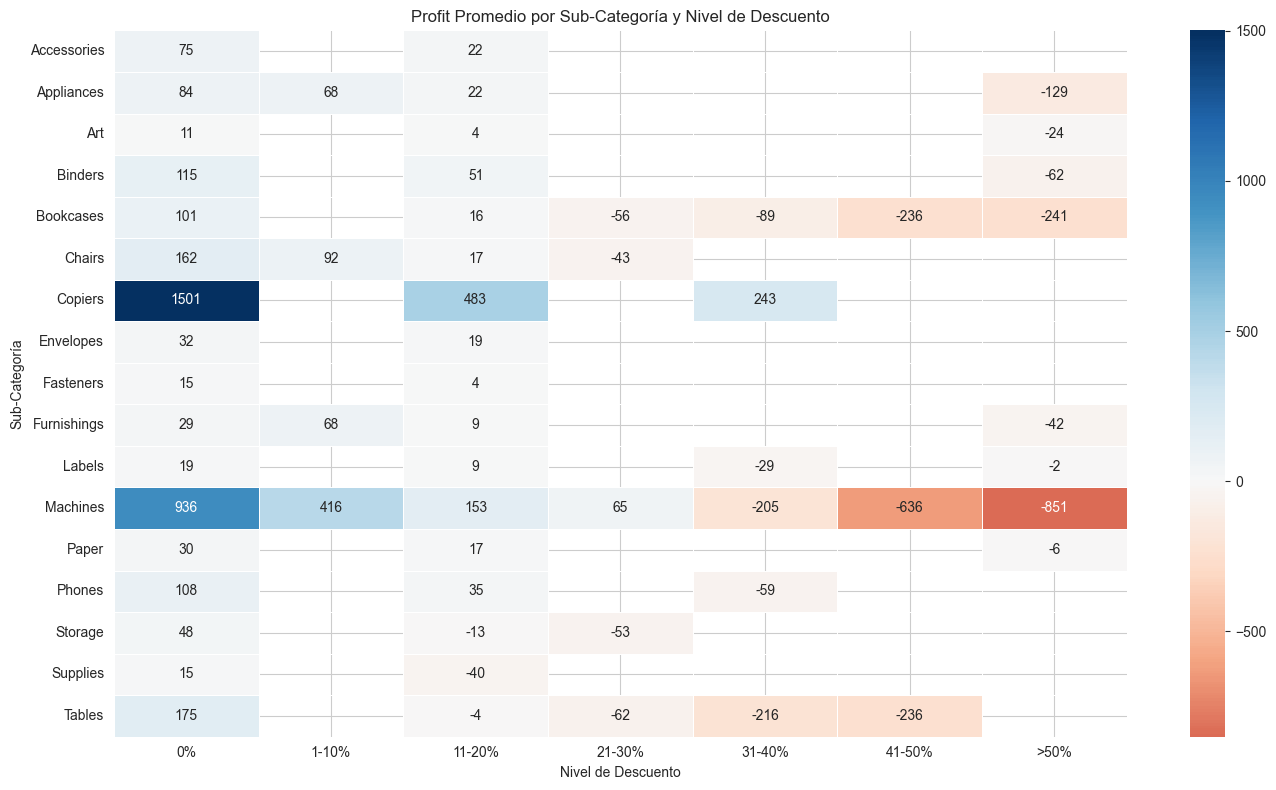

In [45]:
print("--- Profit promedio por nivel de descuento y Sub-Categoría ---")
df['Discount_Bin'] = pd.cut(df['Discount'], bins=[-0.01, 0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.8],
                             labels=['0%', '1-10%', '11-20%', '21-30%', '31-40%', '41-50%', '>50%'])

pivot = df.pivot_table(values='Profit', index='Sub-Category', columns='Discount_Bin', aggfunc='mean')
plt.figure(figsize=(14, 8))
sns.heatmap(pivot, annot=True, fmt='.0f', cmap='RdBu', center=0, linewidths=0.5)
plt.title('Profit Promedio por Sub-Categoría y Nivel de Descuento')
plt.xlabel('Nivel de Descuento')
plt.ylabel('Sub-Categoría')
plt.tight_layout()
plt.show()

## 10. Análisis de Clientes

Identificamos los clientes más valiosos por ventas y por ganancia, analizamos la frecuencia de compra y comparamos la rentabilidad entre segmentos (Consumer, Corporate, Home Office).

--- Top 10 clientes por ventas y por ganancia ---


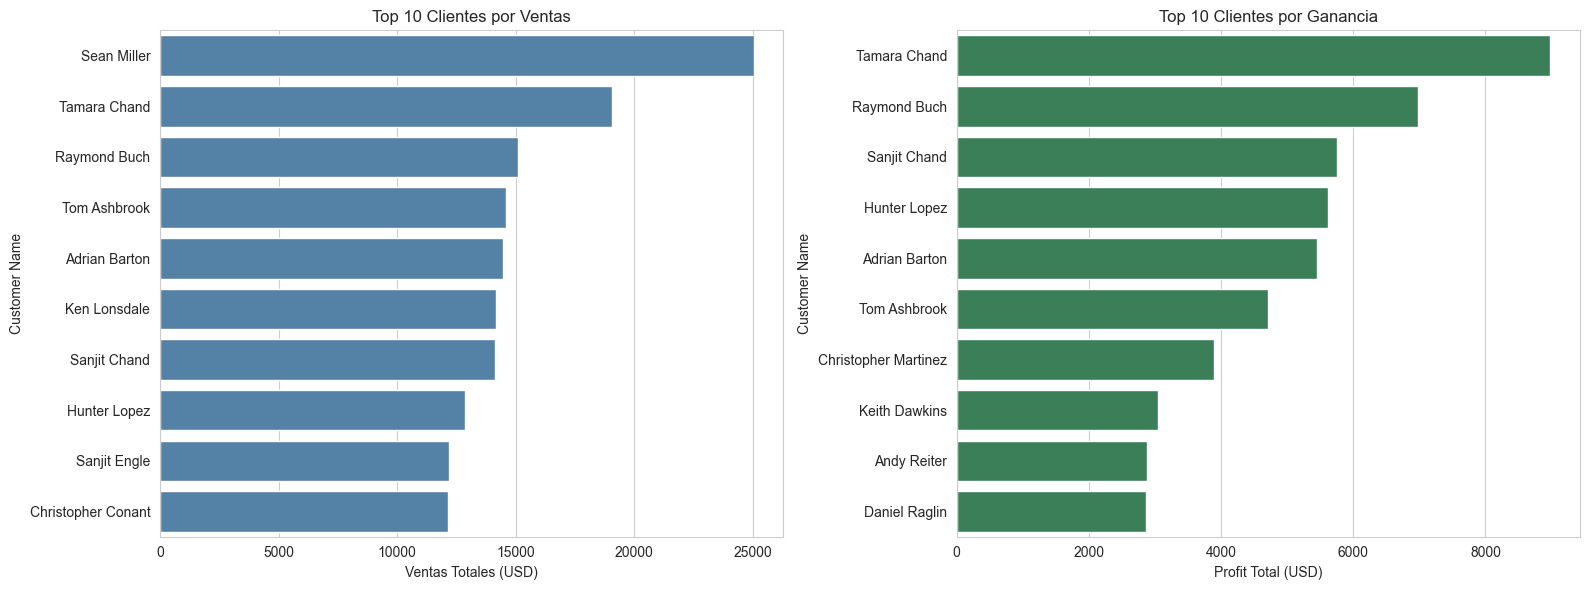

--- Frecuencia de compra por cliente ---


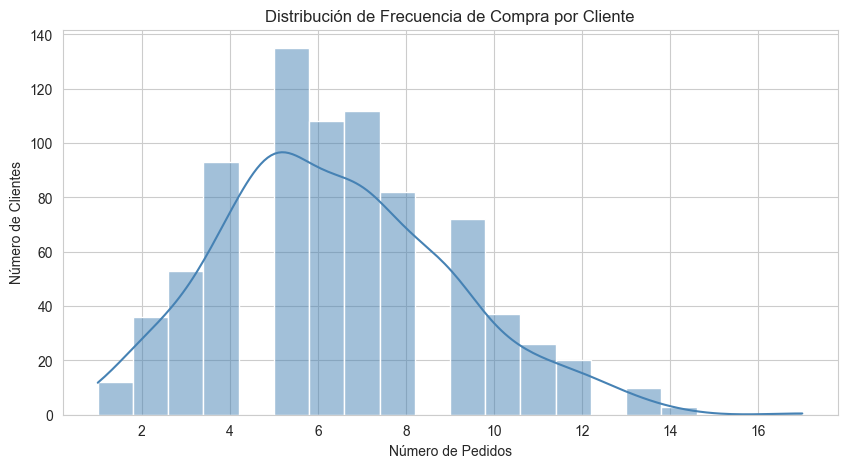

count    800.000000
mean       6.388750
std        2.645538
min        1.000000
25%        5.000000
50%        6.000000
75%        8.000000
max       17.000000

--- Rentabilidad y ventas por Segmento ---


,Segment,Sales,Profit,Pedidos,Margen
0,Consumer,"$1,170,660","$136,371",2628,11.6%
1,Corporate,"$715,806","$94,250",1552,13.2%
2,Home Office,"$440,068","$61,676",931,14.0%


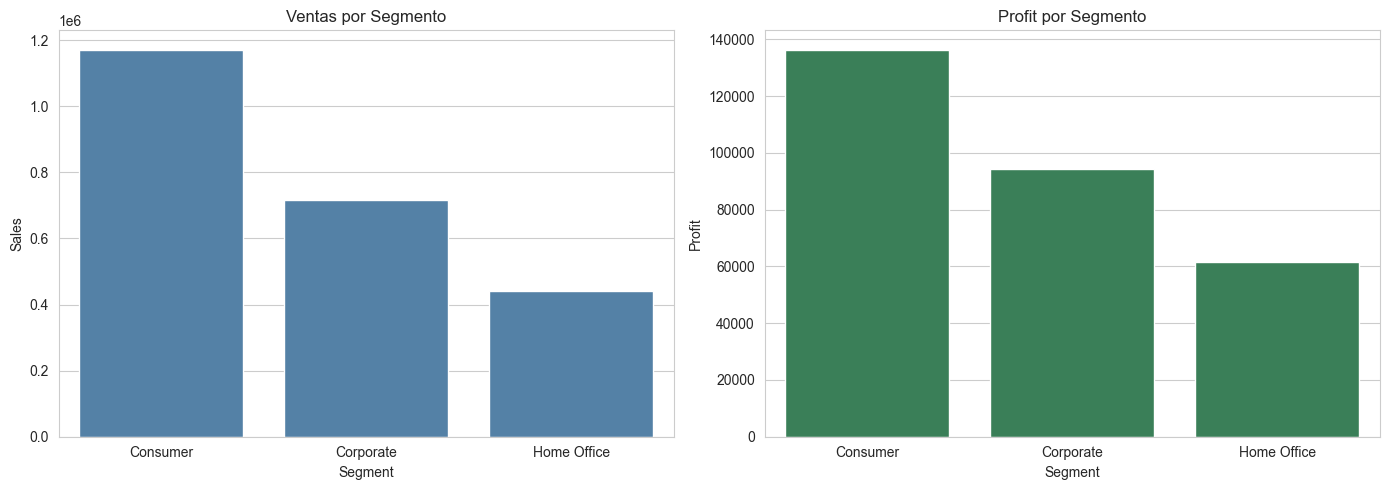

In [46]:
print("--- Top 10 clientes por ventas y por ganancia ---")
top_customers_sales = df.groupby('Customer Name')['Sales'].sum().nlargest(10).reset_index()
top_customers_profit = df.groupby('Customer Name')['Profit'].sum().nlargest(10).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.barplot(data=top_customers_sales, x='Sales', y='Customer Name', color='steelblue', ax=axes[0])
axes[0].set_title('Top 10 Clientes por Ventas')
axes[0].set_xlabel('Ventas Totales (USD)')
sns.barplot(data=top_customers_profit, x='Profit', y='Customer Name', color='seagreen', ax=axes[1])
axes[1].set_title('Top 10 Clientes por Ganancia')
axes[1].set_xlabel('Profit Total (USD)')
plt.tight_layout()
plt.show()

print("--- Frecuencia de compra por cliente ---")
freq = df.groupby('Customer Name')['Order ID'].nunique().reset_index()
freq.columns = ['Customer Name', 'Num_Pedidos']
plt.figure(figsize=(10, 5))
sns.histplot(freq['Num_Pedidos'], bins=20, kde=True, color='steelblue')
plt.title('Distribución de Frecuencia de Compra por Cliente')
plt.xlabel('Número de Pedidos')
plt.ylabel('Número de Clientes')
plt.show()
print(freq['Num_Pedidos'].describe().to_string())

print("\n--- Rentabilidad y ventas por Segmento ---")
seg = df.groupby('Segment').agg(Sales=('Sales','sum'), Profit=('Profit','sum'), Pedidos=('Order ID','nunique')).reset_index()
seg['Margen'] = seg['Profit'] / seg['Sales']
display(seg.style.format({'Sales': '${:,.0f}', 'Profit': '${:,.0f}', 'Margen': '{:.1%}'}))
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(data=seg, x='Segment', y='Sales', color='steelblue', ax=axes[0])
axes[0].set_title('Ventas por Segmento')
sns.barplot(data=seg, x='Segment', y='Profit', color='seagreen', ax=axes[1])
axes[1].set_title('Profit por Segmento')
plt.tight_layout()
plt.show()

## 11. Productos Más y Menos Rentables

Identificamos los productos que generan mayor ganancia y mayor pérdida, y calculamos el margen neto (Profit/Sales) por Sub-Categoría para detectar dónde se pierde dinero estructuralmente.

In [ ]:
print("--- Top 10 productos más rentables ---")
top_profit = df.groupby('Product Name')['Profit'].sum().nlargest(10).reset_index()
plt.figure(figsize=(12, 6))
sns.barplot(data=top_profit, x='Profit', y='Product Name', color='seagreen')
plt.title('Top 10 Productos con Mayor Ganancia')
plt.xlabel('Profit Total (USD)')
plt.tight_layout()
plt.show()

print("--- Top 10 productos con mayor pérdida ---")
top_loss = df.groupby('Product Name')['Profit'].sum().nsmallest(10).reset_index()
plt.figure(figsize=(12, 6))
sns.barplot(data=top_loss, x='Profit', y='Product Name', color='firebrick')
plt.title('Top 10 Productos con Mayor Pérdida')
plt.xlabel('Profit Total (USD)')
plt.tight_layout()
plt.show()

print("--- Margen de ganancia (Profit/Sales) por Sub-Categoría ---")
margin = df.groupby('Sub-Category').agg(Sales=('Sales','sum'), Profit=('Profit','sum'))
margin['Margen'] = margin['Profit'] / margin['Sales']
margin = margin.sort_values('Margen')
plt.figure(figsize=(12, 7))
colors = ['firebrick' if m < 0 else 'seagreen' for m in margin['Margen']]
plt.barh(margin.index, margin['Margen'], color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Margen de Ganancia por Sub-Categoría (Profit / Sales)')
plt.xlabel('Margen')
plt.tight_layout()
plt.show()
display(margin[['Margen']].style.format({'Margen': '{:.1%}'}).background_gradient(cmap='RdYlGn', axis=0))

## 12. Análisis de Correlación Avanzado (Pairplot)

Un `pairplot` entre todas las variables numéricas, coloreado por `Category`, revela interacciones que la matriz de correlación no captura, como clusters o relaciones no lineales entre grupos.

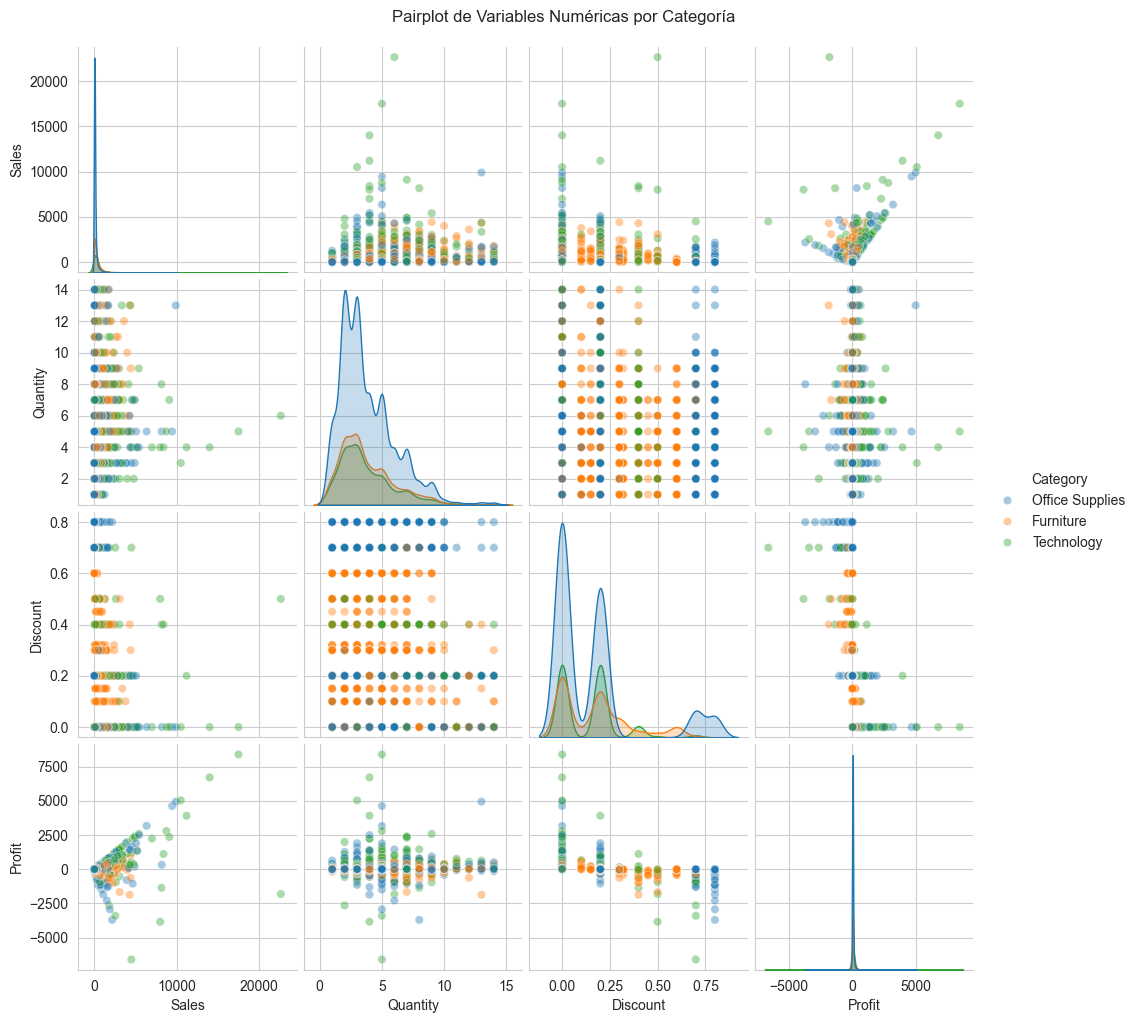

In [52]:
pair_cols = numerical_cols + ['Profit']
g = sns.pairplot(df[pair_cols + ['Category']], hue='Category', plot_kws={'alpha': 0.4}, height=2.5)
g.figure.suptitle('Pairplot de Variables Numéricas por Categoría', y=1.02)
plt.show()

## 13. Conclusiones Generales

### Rentabilidad y Variable Objetivo (`Profit`)
- El **~25% de las transacciones generan pérdidas**, lo que indica un problema estructural que no puede atribuirse a casos aislados.
- La distribución de `Profit` es altamente asimétrica con outliers extremos en ambos sentidos (pérdidas de hasta -$6.600 y ganancias de hasta $8.400).
- Si se clasifica en transacciones 'Rentables' (Profit > 0) vs. 'No Rentables' (Profit ≤ 0), existe un **desbalance relevante** que debe considerarse en cualquier modelo predictivo.

### Variables con Mayor Relación con el Target
- **`Sales`:** Correlación positiva moderada. Mayores ventas tienden a generar más ganancia, pero la dispersión en los scatterplots confirma que no es una relación lineal simple.
- **`Discount`:** Variable con **mayor correlación negativa con Profit**. Descuentos superiores al 20–30% generan pérdidas en la mayoría de sub-categorías. Sub-categorías como **Tables** y **Bookcases** pierden dinero incluso con descuentos bajos.
- **`Quantity`:** Correlación positiva débil. Vender más unidades no garantiza ganancia si los descuentos son altos.
- **`Category` y `Sub-Category`:** Impacto significativo. **Technology** y **Office Supplies** son las más rentables; **Furniture** concentra las mayores pérdidas.
- **`Region`, `State/Province`:** La ubicación influye. Las regiones **Central y South** concentran más pérdidas que **East y West**.

### Patrones Temporales
- Las ventas y el profit presentan **picos en Q4** (noviembre–diciembre), lo que indica estacionalidad relevante para planificación de inventario y descuentos.
- Los meses de enero–febrero tienen márgenes más ajustados aunque no son consistentemente deficitarios.

### Geografía y Segmentos
- El segmento **Consumer** genera el mayor volumen de ventas, pero **Corporate** tiene un margen porcentual ligeramente superior.
- **Home Office** es el segmento más pequeño con rentabilidad similar a Corporate.

### Clientes y Productos
- El top 10 de clientes por profit no coincide con el top 10 por ventas: **volumen de compra no garantiza rentabilidad**.
- Los productos con mayor pérdida pertenecen principalmente a **Furniture** con descuentos aplicados.
- La mayoría de los clientes realizan entre 1 y 5 pedidos únicos; hay pocos clientes de alta frecuencia.

### Variables que Requieren Transformación
- **`Profit`, `Sales`, `Quantity`, `Discount`** presentan alta asimetría y numerosos outliers. Se recomienda aplicar transformaciones (logarítmica, raíz cuadrada) antes de utilizarlas en modelos que asumen normalidad.
- Las variables de fecha ya fueron convertidas a `datetime`; se pueden derivar características temporales (año, mes, día de la semana, duración de envío).

### Variables Redundantes
- **`Row ID`, `Order ID`, `Customer ID`, `Product ID`:** Identificadores sin valor predictivo directo.
- **`Customer Name`, `Product Name`:** Texto libre no utilizable directamente sin NLP.
- **`Country/Region`:** Prácticamente constante (casi todos los registros son de EE. UU.), por lo que aporta poca variabilidad.

### Variables Seleccionadas para el Modelado (Propuesta Inicial)
- **Numéricas:** `Sales`, `Quantity`, `Discount`
- **Categóricas:** `Ship Mode`, `Segment`, `Region`, `State/Province`, `Category`, `Sub-Category` (y `City` con manejo de alta cardinalidad)
- **Temporales derivadas:** duración de envío, año, mes y día de la semana del pedido

### Recomendaciones para el Negocio
1. **Limitar descuentos en Furniture:** especialmente en Tables y Bookcases, donde el margen ya es negativo sin descuento.
2. **Aprovechar el pico de Q4:** concentrar promociones en productos con margen alto (Technology).
3. **Revisar política de precios en Central y South:** estas regiones muestran rentabilidad consistentemente menor.
4. **Priorizar clientes Corporate:** ofrece mejor margen proporcional que Consumer con menor volumen de transacciones problemáticas.